In [1]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")

Downloaded thinkstats.py


In [2]:
try:
    import empiricaldist
except ImportError:
    %pip install empiricaldist

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for empiricaldist: filename=empiricaldist-0.9.0-py3-none-any.whl size=14297 sha256=9116076c228f743344d43d7e07c7d9112fbd0c8edbea363f85dda0387e1fdedd
  Stored in directory: /root/.cache/pip/wheels/26/56/da/ea90b6b66dc5e72379a64e2819815066873f00c1350126e876
Successfully built empiricaldist


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thinkstats import decorate

In [4]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/relay.py")
download(
    "https://github.com/AllenDowney/ThinkStats/raw/v3/data/Apr25_27thAn_set1.shtml"
)

Downloaded relay.py
Downloaded Apr25_27thAn_set1.shtml


In [5]:
from relay import read_results

results = read_results()
results.head()

,Place,Div/Tot,Division,Guntime,Nettime,Min/Mile,MPH
0,1,1/362,M2039,30:43,30:42,4:57,12.121212
1,2,2/362,M2039,31:36,31:36,5:06,11.764706
2,3,3/362,M2039,31:42,31:42,5:07,11.726384
3,4,4/362,M2039,32:28,32:27,5:14,11.464968
4,5,5/362,M2039,32:52,32:52,5:18,11.320755


In [6]:
speeds = results["MPH"].values

In [7]:
my_result = results.query("Nettime == '42:44'")
my_result

,Place,Div/Tot,Division,Guntime,Nettime,Min/Mile,MPH
96,97,26/256,M4049,42:48,42:44,6:53,8.716707


In [8]:
my_speed = speeds[96]

In [9]:
(speeds <= my_speed).sum()

np.int64(1537)

In [10]:
(speeds <= my_speed).mean() * 100

np.float64(94.12124923453766)

In [11]:
def percentile_rank(x, seq):
    """Percentile rank of x.

    x: value
    seq: sequence of values

    returns: percentile rank 0-100
    """
    return (seq <= x).mean() * 100

In [12]:
my_division = results.query("Division == 'M4049'")
my_division_speeds = my_division["MPH"].values

In [13]:
percentile_rank(my_speed, my_division_speeds)

np.float64(90.234375)

In [14]:
def percentile(p, seq):
    n = len(seq)
    i = (1 - p / 100) * (n + 1)
    return seq[round(i)]

In [15]:
percentile(90, my_division_speeds)

np.float64(8.591885441527447)

In [16]:
next_division = results.query("Division == 'M5059'")
next_division_speeds = next_division["MPH"].values

percentile(90.2, next_division_speeds)

np.float64(8.017817371937639)

In [17]:
next_division.query("MPH > 8.01").tail(1)

,Place,Div/Tot,Division,Guntime,Nettime,Min/Mile,MPH
222,223,18/171,M5059,46:30,46:25,7:29,8.017817


In [18]:
t = [1, 2, 2, 3, 5]

In [19]:
from empiricaldist import Pmf

pmf = Pmf.from_seq(t)
pmf

,
1,0.2
2,0.4
3,0.2
5,0.2


In [20]:
pmf[2]

np.float64(0.4)

In [21]:
cdf = pmf.make_cdf()
cdf

,
1,0.2
2,0.6
3,0.8
5,1.0


In [22]:
cdf[2]

np.float64(0.6000000000000001)

In [23]:
cdf(3)

array(0.8)

In [24]:
cdf(4)

array(0.8)

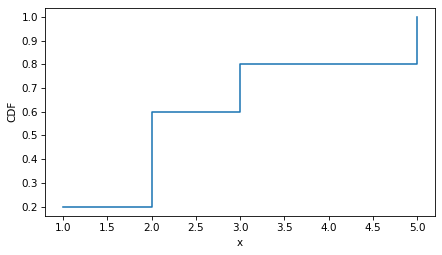

In [25]:
cdf.step()
decorate(xlabel="x", ylabel="CDF")

In [26]:
from empiricaldist import Cdf

cdf_speeds = Cdf.from_seq(speeds)

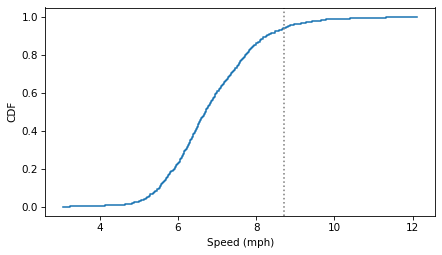

In [27]:
cdf_speeds.step()
plt.axvline(my_speed, ls=":", color="gray")
decorate(xlabel="Speed (mph)", ylabel="CDF")

In [28]:
cdf_speeds(my_speed) * 100

np.float64(94.12124923453766)

In [29]:
cdf_speeds.inverse(0.5)

array(6.70391061)

In [30]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/nsfg.py")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dct")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dat.gz")

Downloaded nsfg.py
Downloaded 2002FemPreg.dct
Downloaded 2002FemPreg.dat.gz


In [31]:
try:
    import statadict
except ImportError:
    %pip install statadict

In [32]:
from nsfg import get_nsfg_groups

live, firsts, others = get_nsfg_groups()

In [33]:
first_weights = firsts["totalwgt_lb"].dropna()
first_weights.mean()

np.float64(7.201094430437772)

In [34]:
other_weights = others["totalwgt_lb"].dropna()
other_weights.mean()

np.float64(7.325855614973262)

In [35]:
from empiricaldist import Pmf

first_pmf = Pmf.from_seq(first_weights, name="first")
other_pmf = Pmf.from_seq(other_weights, name="other")

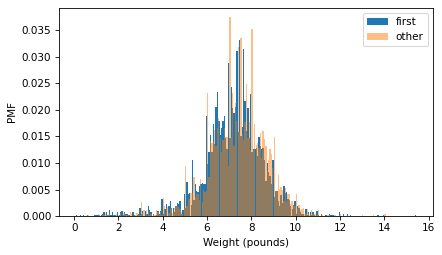

In [36]:
from thinkstats import two_bar_plots

two_bar_plots(first_pmf, other_pmf, width=0.06)
decorate(xlabel="Weight (pounds)", ylabel="PMF")

In [37]:
first_cdf = first_pmf.make_cdf()
other_cdf = other_pmf.make_cdf()

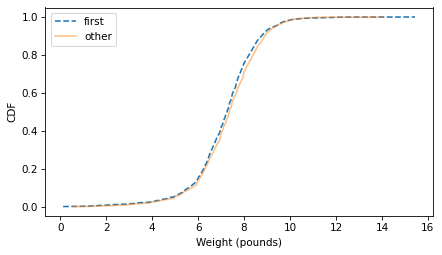

In [38]:
first_cdf.plot(ls="--")
other_cdf.plot(alpha=0.5)
decorate(xlabel="Weight (pounds)", ylabel="CDF")

In [39]:
from nsfg import read_stata

dct_file = "2002FemPreg.dct"
dat_file = "2002FemPreg.dat.gz"

preg = read_stata(dct_file, dat_file)

In [40]:
birthwgt_lb = preg["birthwgt_lb"]
birthwgt_oz = preg["birthwgt_oz"]

In [41]:
from empiricaldist import Hist

Hist.from_seq(birthwgt_oz).tail(5)

,
birthwgt_oz,
14.0,475
15.0,378
97.0,1
98.0,1
99.0,46


In [42]:
Hist.from_seq(birthwgt_lb).tail(5)

,
birthwgt_lb,
15.0,1
51.0,1
97.0,1
98.0,1
99.0,57


In [43]:
birthwgt_lb_clean = birthwgt_lb.replace([51, 97, 98, 99], np.nan)
birthwgt_oz_clean = birthwgt_oz.replace([97, 98, 99], np.nan)

total_weight_clean = birthwgt_lb_clean + birthwgt_oz_clean / 16

In [44]:
total_weight_bogus = birthwgt_lb + birthwgt_oz / 16

In [45]:
count1, count2 = total_weight_bogus.count(), total_weight_clean.count()
diff = count1 - count2

diff, diff / count2 * 100

(np.int64(49), np.float64(0.5421553441026776))

In [46]:
mean1, mean2 = total_weight_bogus.mean(), total_weight_clean.mean()
mean1, mean2

(np.float64(7.319680587652691), np.float64(7.265628457623368))

In [47]:
(mean1 - mean2) / mean2 * 100

np.float64(0.74394294099376)

In [48]:
std1, std2 = total_weight_bogus.std(), total_weight_clean.std()
std1, std2

(2.0960017791618313, 1.4082934455690168)

In [49]:
(std1 - std2) / std2 * 100

48.832744039005874

In [50]:
def skewness(seq):
    """Compute the skewness of a sequence

    seq: sequence of numbers

    returns: float skewness
    """
    deviations = seq - seq.mean()
    return np.mean(deviations**3) / seq.std(ddof=0) ** 3

In [51]:
skew1, skew2 = skewness(total_weight_bogus), skewness(total_weight_clean)
skew1, skew2

(np.float64(22.251846195422598), np.float64(-0.5895062687577703))

In [52]:
# how much is skew1 off by?
(skew1 - skew2) / skew2

np.float64(-38.74658112171143)

In [53]:
cdf_total_weight_bogus = Cdf.from_seq(total_weight_bogus)
cdf_total_weight_clean = Cdf.from_seq(total_weight_clean)

In [54]:
def median(cdf):
    m = cdf.inverse(0.5)
    return m

In [55]:
median(cdf_total_weight_bogus), median(cdf_total_weight_clean)

(array(7.375), array(7.375))

In [56]:
def iqr(cdf):
    low, high = cdf.inverse([0.25, 0.75])
    return high - low

In [57]:
iqr(cdf_total_weight_bogus), iqr(cdf_total_weight_clean)

(np.float64(1.625), np.float64(1.625))

In [58]:
def quartile_skewness(cdf):
    low, median, high = cdf.inverse([0.25, 0.5, 0.75])
    midpoint = (high + low) / 2
    semi_iqr = (high - low) / 2
    return (midpoint - median) / semi_iqr

In [59]:
qskew1 = quartile_skewness(cdf_total_weight_bogus)
qskew2 = quartile_skewness(cdf_total_weight_clean)
qskew1, qskew2

(np.float64(-0.07692307692307693), np.float64(-0.07692307692307693))

In [60]:
def sample_from_cdf(cdf, n):
    ps = np.random.random(size=n)
    return cdf.inverse(ps)

In [61]:
sample = sample_from_cdf(cdf_speeds, 1001)

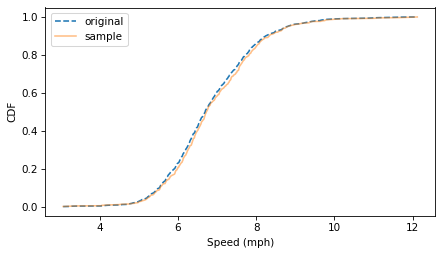

In [62]:
cdf_sample = Cdf.from_seq(sample)

cdf_speeds.plot(label="original", ls="--")
cdf_sample.plot(label="sample", alpha=0.5)

decorate(xlabel="Speed (mph)", ylabel="CDF")

In [63]:
percentile_ranks = cdf_speeds(sample) * 100

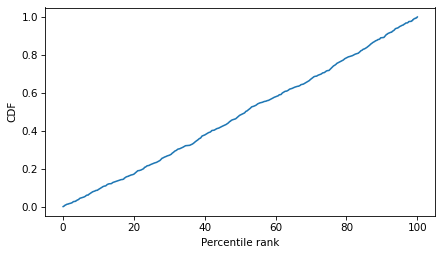

In [64]:
cdf_percentile_rank = Cdf.from_seq(percentile_ranks)
cdf_percentile_rank.plot()

decorate(xlabel="Percentile rank", ylabel="CDF")

In [65]:
sample = cdf_speeds.sample(1001)

## Exercises

In [66]:
from nsfg import get_nsfg_groups

live, firsts, others = get_nsfg_groups()

In [67]:
from nsfg import read_fem_resp, read_fem_preg
from empiricaldist import Cdf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

preg = read_fem_preg()
preg.shape

(13593, 244)

In [69]:
from nsfg import read_fem_preg

preg = read_fem_preg()

# Exercise 4.1

# Select live births
live = preg.query("outcome == 1")

# Birth weight in pounds + ounces
birth_weight = live['totalwgt_lb'].dropna()

# Your birth weight
my_weight = 8.5

# Overall CDF
cdf_all = Cdf.from_seq(birth_weight)

# Percentile rank
percentile = cdf_all[my_weight] * 100

print("Overall percentile rank:", percentile)

Overall percentile rank: 84.06727152024784


In [71]:
# First babies
firsts = live.query("birthord == 1")

# Others
others = live.query("birthord != 1")

# Create CDFs
cdf_first = Cdf.from_seq(firsts['totalwgt_lb'].dropna())
cdf_other = Cdf.from_seq(others['totalwgt_lb'].dropna())

# Example: assume not first baby
percentile_other = cdf_other[my_weight] * 100

print("Percentile among others:", percentile_other)

Percentile among others: 82.35294117647058


In [72]:
male = live.query("babysex == 1")
female = live.query("babysex == 2")
len(male), len(female)

(4641, 4500)

In [73]:
# Exercise 4.2

# Male babies
male = live.query("babysex == 1")

# Female babies
female = live.query("babysex == 2")

# Create CDFs
cdf_male = Cdf.from_seq(male['totalwgt_lb'].dropna())
cdf_female = Cdf.from_seq(female['totalwgt_lb'].dropna())

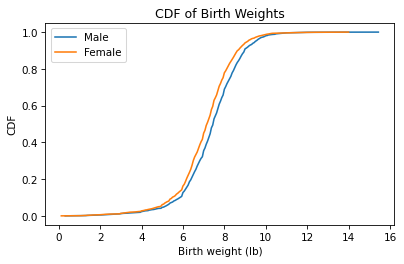

In [74]:
# Plot CDFs

cdf_male.plot(label='Male')
cdf_female.plot(label='Female')

plt.xlabel("Birth weight (lb)")
plt.ylabel("CDF")
plt.title("CDF of Birth Weights")
plt.legend()

plt.show()

In [76]:
# Percentile rank of 8.5 lb male baby
male_percentile = cdf_male[8.5]

print("Male percentile rank:", male_percentile * 100)

Male percentile rank: 80.65430752453653


In [77]:
# Female weight with same percentile rank

female_weight = cdf_female.inverse(male_percentile)

print("Equivalent female weight:", female_weight)

Equivalent female weight: 8.1875


In [78]:
from nsfg import read_fem_preg

preg = read_fem_preg()

In [80]:
# Exercise 4.3

# Age at conception
agepreg = preg['agepreg'].dropna()

# Create CDF
cdf_age = Cdf.from_seq(agepreg)

# Percentages
less_20 = cdf_age[20] * 100
less_30 = cdf_age[30] * 100

between_20_30 = less_30 - less_20

print("<= 20 years:", less_20)
print("<= 30 years:", less_30)
print("Between 20 and 30:", between_20_30)

<= 20 years: 24.718676837096893
<= 30 years: 80.46220074012537
Between 20 and 30: 55.743523903028475


Median: 8.3
Q1: 7.7
Q3: 9.0
IQR: 1.2999999999999998
Quartile skewness: 0.07692307692307529


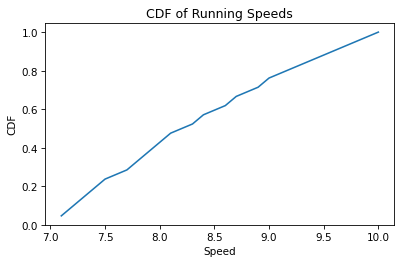

In [81]:
# Exercise 4.4

# Running speeds
speeds = [
    7.1, 7.2, 7.3, 7.4, 7.5, 7.7, 7.8, 7.9,
    8.0, 8.1, 8.3, 8.4, 8.6, 8.7, 8.9, 9.0,
    9.2, 9.4, 9.6, 9.8, 10.0
]

# Create CDF
cdf_speed = Cdf.from_seq(speeds)

# Median
median = cdf_speed.inverse(0.5)

# Quartiles
q1 = cdf_speed.inverse(0.25)
q3 = cdf_speed.inverse(0.75)

# IQR
iqr = q3 - q1

# Quartile skewness
quartile_skewness = ((q3 + q1) - 2 * median) / iqr

print("Median:", median)
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Quartile skewness:", quartile_skewness)

# Plot CDF

cdf_speed.plot()

plt.xlabel("Speed")
plt.ylabel("CDF")
plt.title("CDF of Running Speeds")

plt.show()

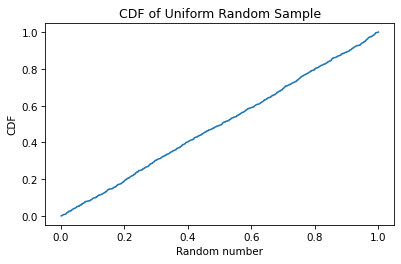

In [82]:
#Exercise 4.5

# Generate random sample
sample = np.random.random(1001)

# Create CDF
cdf_random = Cdf.from_seq(sample)

# Plot CDF

cdf_random.plot()

plt.xlabel("Random number")
plt.ylabel("CDF")
plt.title("CDF of Uniform Random Sample")

plt.show()

In [83]:
t = np.random.random(1001)